## LightFM Hybrid Recommendation System for Student Projects

This notebook implements a **hybrid recommendation system** for student projects using the **LightFM library** that combines:
- **Collaborative filtering**: Explicit ratings (1-5 scale) from artificial_profiles_scores.pkl
- **Content-based filtering**: User features from artificial_profiles.json (bios and tags)
- **Content-based filtering**: Item features from titles_with_tags_dict.pkl (project tags)

## Setup
- **Items**: Project titles with their associated tags
- **Users**: 31 artificial profiles with bios and tags
- **Interactions**: User-item ratings (treated as interaction weights)
- **Hybrid approach**: Combines collaborative signals with content features for better recommendations, especially for cold-start scenarios

In [1]:
import numpy as np
import pandas as pd
import pickle
import json
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer

from lightfm import LightFM
import warnings

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")

/Users/antonshishkov/Projects/diploma/.venv/lib/python3.14/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## Load Data

In [2]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    interactions = pickle.load(f)

with open("artificial_profiles.json", "r", encoding="utf-8") as f:
    user_features = json.load(f)

with open("titles_with_tags_dict.pkl", "rb") as f:
    item_features = pickle.load(f)

print("Data loaded successfully:")
print(f"  - Users: {len(interactions)}")
print(f"  - Items: {len(item_features)}")
print(f"  - Total interactions: {sum(len(ratings) for ratings in interactions.values())}")

Data loaded successfully:
  - Users: 31
  - Items: 1164
  - Total interactions: 359


In [3]:
sample_user = list(user_features.keys())[0]
print(f"Sample user: {sample_user}")
print(f"Bio: {user_features[sample_user]['bio'][:200]}...")
print(f"Tags: {user_features[sample_user]['tags']}")

Sample user: global_economics_and_geopolitics_analyst
Bio: A highly analytical researcher deeply engaged in monitoring global economic trends, geopolitical risks, international trade, and the socio-economic development of various regions (especially BRICS, As...
Tags: ['global_economy', 'geopolitics', 'macroeconomics', 'international_economics', 'data_analysis', 'forex', 'regional_development', 'brics', 'political_economy', 'international_relations', 'data_monitoring', 'time_series', 'system_thinking', 'geopolitics_of_BRICS', 'investment_analysis', 'economic_forecasting', 'trade_policy', 'market_forecasting', 'data_mining', 'quantitative_finance', 'global_systems', 'regional_analysis', 'economic_development']


In [4]:
sample_item = list(item_features.keys())[0]
print(f"Sample item: {sample_item[:80]}...")
print(f"Tags: {item_features[sample_item]}")

Sample item: Исследование приоритетов и механизмов реализации отраслевых (секторальных) полит...
Tags: ['international_relations', 'political_economics', 'policy_analysis', 'BRICS', 'geopolitics', 'international_policy', 'comparative_politics']


## Analyze Data Distribution

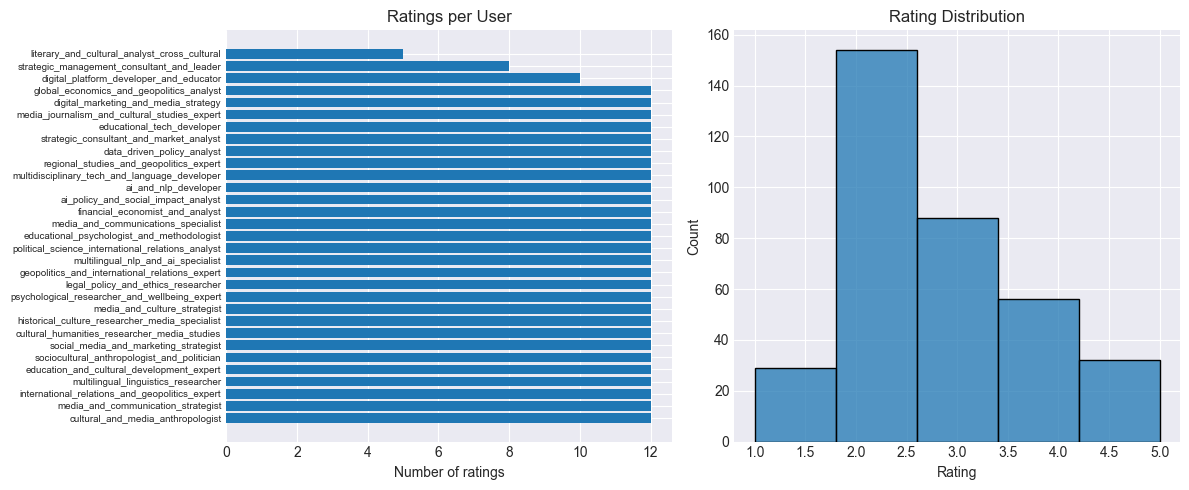


Rating statistics:
  Mean: 2.74
  Std: 1.09
  Min: 1
  Max: 5


In [5]:
user_ratings_counts = {}
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    user_ratings_counts[user] = len(valid_ratings)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.barh(range(len(user_ratings_counts)), sorted(user_ratings_counts.values(), reverse=True))
plt.yticks(range(len(user_ratings_counts)), [list(user_ratings_counts.keys())[i] for i in np.argsort(list(user_ratings_counts.values()))[::-1]], fontsize=7)
plt.xlabel('Number of ratings')
plt.title('Ratings per User')
plt.tight_layout()

plt.subplot(1, 2, 2)
all_ratings = []
for user_ratings in interactions.values():
    all_ratings.extend([r for r in user_ratings.values() if r is not None])
sns.histplot(all_ratings, bins=5, kde=False)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.title('Rating Distribution')
plt.tight_layout()
plt.show()

print(f"\nRating statistics:")
print(f"  Mean: {np.mean(all_ratings):.2f}")
print(f"  Std: {np.std(all_ratings):.2f}")
print(f"  Min: {np.min(all_ratings)}")
print(f"  Max: {np.max(all_ratings)}")

## Build User and Item Mappings

In [6]:
user_ids = sorted(interactions.keys())
item_ids = sorted(item_features.keys())

num_users = len(user_ids)
num_items = len(item_ids)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(item_ids)}

print(f"User mapping created: {num_users} users")
print(f"Item mapping created: {num_items} items")

User mapping created: 31 users
Item mapping created: 1164 items


## Build User-Item Interaction Matrix

In [7]:
row_indices = []
col_indices = []
ratings = []

for user, user_ratings in interactions.items():
    if user not in user_to_idx:
        continue
    user_idx = user_to_idx[user]
    
    for project_json, rating in user_ratings.items():
        if rating is not None and rating > 0:
            try:
                # Parse JSON string to extract title
                project_data = json.loads(project_json)
                project_title = project_data['title']
                
                if project_title in item_to_idx:
                    item_idx = item_to_idx[project_title]
                    row_indices.append(user_idx)
                    col_indices.append(item_idx)
                    ratings.append(rating)
            except (json.JSONDecodeError, KeyError):
                continue

interaction_matrix = csr_matrix(
    (ratings, (row_indices, col_indices)), shape=(num_users, num_items)
)

print(f"Interaction matrix shape: {interaction_matrix.shape}")
print(f"Number of interactions: {len(ratings)}")
print(f"Sparsity: {len(ratings) / (num_users * num_items) * 100:.2f}%")

Interaction matrix shape: (31, 1164)
Number of interactions: 359
Sparsity: 0.99%


In [8]:
user_tags = []
for user in user_ids:
    tags = user_features[user]['tags'] if user in user_features else []
    user_tags.append(tags)

all_user_tags = set()
for tags in user_tags:
    all_user_tags.update(tags)

# Check tag overlap between users and items
item_tags = [item_features[item] for item in item_ids]
all_item_tags = set()
for tags in item_tags:
    all_item_tags.update(tags)

shared_tags = all_user_tags & all_item_tags

print(f"Unique user tags: {len(all_user_tags)}")
print(f"Unique item tags: {len(all_item_tags)}")
print(f"Shared tags: {len(shared_tags)}")
print(f"Tag overlap: {len(shared_tags) / max(len(all_item_tags), 1) * 100:.1f}%")
print(f"\nSample shared tags: {list(shared_tags)[:10]}")

Unique user tags: 198
Unique item tags: 1861
Shared tags: 190
Tag overlap: 10.2%

Sample shared tags: ['Japanese_language', 'economic_forecasting', 'cultural_studies', 'data_collection', 'energy_security', 'time_series', 'social_psychology', 'analytics', 'visual_communication', 'education_technology']


## Extract and Process User Features

In [9]:
user_bios = [user_features[user]['bio'] for user in user_ids]

# Use more bio features for better content representation
bio_vectorizer = TfidfVectorizer(max_features=100, stop_words='english', ngram_range=(1, 2))
bio_features = bio_vectorizer.fit_transform(user_bios)

# Use ALL tags (not just shared) to capture more information
# Create unified tag vocabulary from both users and items
all_tags_unified = sorted(list(all_user_tags | all_item_tags))

print(f"Unified tag vocabulary size: {len(all_tags_unified)}")
print(f"  - From users only: {len(all_user_tags - all_item_tags)}")
print(f"  - From items only: {len(all_item_tags - all_user_tags)}")
print(f"  - Shared: {len(all_user_tags & all_item_tags)}")

# Use unified tag encoder for both users and items
unified_tag_encoder = MultiLabelBinarizer(classes=all_tags_unified)
user_tag_features = unified_tag_encoder.fit_transform(user_tags)
item_tag_features = unified_tag_encoder.transform(item_tags)

# Normalize bio features
from sklearn.preprocessing import normalize
bio_features_normalized = normalize(bio_features, norm='l2', axis=1)

# Combine normalized bio features with tag features
user_features_dense = np.hstack([bio_features_normalized.toarray(), user_tag_features])

# LightFM expects feature matrix of shape (n_features, n_users) with identity included
identity = np.eye(num_users)
user_feature_matrix = csr_matrix(np.vstack([identity, user_features_dense.T]))

print(f"\nUser feature matrix shape: {user_feature_matrix.shape}")
print(f"  - Identity features: {num_users}")
print(f"  - Bio features: {bio_features_normalized.shape[1]}")
print(f"  - Tag features: {user_tag_features.shape[1]}")
print(f"  - Total features: {user_feature_matrix.shape[0]}")

Unified tag vocabulary size: 1869
  - From users only: 8
  - From items only: 1671
  - Shared: 190

User feature matrix shape: (2000, 31)
  - Identity features: 31
  - Bio features: 100
  - Tag features: 1869
  - Total features: 2000


## Extract and Process Item Features

In [10]:
# item_tag_features is already defined in cell 14 using unified_tag_encoder
# No need to re-encode, just use the already computed features

# Create identity matrix for unique item features
identity = np.eye(num_items)

# Combine identity with tag features
item_feature_matrix = csr_matrix(np.vstack([identity, item_tag_features.T]))

print(f"Item feature matrix shape: {item_feature_matrix.shape}")
print(f"  - Identity features: {num_items}")
print(f"  - Tag features: {item_tag_features.shape[1]}")
print(f"  - Total features: {item_feature_matrix.shape[0]}")

Item feature matrix shape: (3033, 1164)
  - Identity features: 1164
  - Tag features: 1869
  - Total features: 3033


## Split Data into Train and Test Sets

In [11]:
rows, cols = interaction_matrix.nonzero()
n_ratings = len(rows)

rating_indices = np.arange(n_ratings)
train_indices, test_indices = train_test_split(
    rating_indices, test_size=0.2, random_state=42, stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_ratings = np.array([interaction_matrix[r, c] for r, c in zip(train_rows, train_cols)])

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_ratings = np.array([interaction_matrix[r, c] for r, c in zip(test_rows, test_cols)])

train_matrix = csr_matrix(
    (train_ratings, (train_rows, train_cols)), shape=(num_users, num_items)
)

print(f"Original ratings: {n_ratings}")
print(f"Training ratings: {len(train_indices)} ({len(train_indices)/n_ratings*100:.1f}%)")
print(f"Test ratings: {len(test_indices)} ({len(test_indices)/n_ratings*100:.1f}%)")

Original ratings: 359
Training ratings: 287 (79.9%)
Test ratings: 72 (20.1%)


## Split Training Data into Final Train and Validation Sets

In [12]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)), test_size=0.2, random_state=42, stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_ratings = np.array([interaction_matrix[r, c] for r, c in zip(final_train_rows, final_train_cols)])

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_ratings = np.array([interaction_matrix[r, c] for r, c in zip(val_rows, val_cols)])

final_train_matrix = csr_matrix(
    (final_train_ratings, (final_train_rows, final_train_cols)), shape=(num_users, num_items)
)

print(f"Final training data: {len(final_train_indices)} ratings")
print(f"Validation data: {len(val_indices)} ratings")
print(f"Test data: {len(test_indices)} ratings")

Final training data: 229 ratings
Validation data: 58 ratings
Test data: 72 ratings


## Initialize Hybrid LightFM Model

In [13]:
# Initialize with better hyperparameters based on sparse data characteristics
model = LightFM(
    no_components=20,  # More components for better representation
    loss='warp',  # WARP works well for implicit feedback
    learning_rate=0.03,  # Lower learning rate for more stable training
    item_alpha=0.02,  # Slightly higher regularization to prevent overfitting
    user_alpha=0.02,
    random_state=42,
)

print("Hybrid LightFM model initialized:")
print(f"  - Components (factors): {model.no_components}")
print(f"  - Loss function: {model.loss}")
print(f"  - Learning rate: {model.learning_rate}")
print(f"  - User feature matrix shape: {user_feature_matrix.shape}")
print(f"  - Item feature matrix shape: {item_feature_matrix.shape}")
print(f"\nFeature breakdown:")
print(f"  User features: {num_users} (identity) + {bio_features.shape[1]} (bio) + {user_tag_features.shape[1]} (tags)")
print(f"  Item features: {num_items} (identity) + {item_tag_features.shape[1]} (tags)")
print("\nModel combines:")
print("  - Collaborative filtering from interaction matrix")
print("  - Content-based filtering from user features (bio + tags)")
print("  - Content-based filtering from item features (tags)")
print("\nNote: Using unified tag vocabulary for better feature alignment")

Hybrid LightFM model initialized:
  - Components (factors): 20
  - Loss function: warp
  - Learning rate: 0.03
  - User feature matrix shape: (2000, 31)
  - Item feature matrix shape: (3033, 1164)

Feature breakdown:
  User features: 31 (identity) + 100 (bio) + 1869 (tags)
  Item features: 1164 (identity) + 1869 (tags)

Model combines:
  - Collaborative filtering from interaction matrix
  - Content-based filtering from user features (bio + tags)
  - Content-based filtering from item features (tags)

Note: Using unified tag vocabulary for better feature alignment


## Train Hybrid Model

In [14]:
n_epochs = 30

print("Training hybrid LightFM model with user and item features...")

model.fit(
    interactions=final_train_matrix,
    user_features=user_feature_matrix,
    item_features=item_feature_matrix,
    sample_weight=final_train_matrix.tocoo(),
    epochs=n_epochs,
    verbose=True
)

print(f"\nTraining completed after {n_epochs} epochs")

Training hybrid LightFM model with user and item features...


Epoch: 100%|██████████| 30/30 [00:00<00:00, 1745.28it/s]


Training completed after 30 epochs


## Evaluate Model Performance

In [15]:
def predict_for_pairs(model, rows, cols):
    predictions = model.predict(rows, cols)
    return predictions

train_predictions = predict_for_pairs(model, final_train_rows, final_train_cols)
train_mse = mean_squared_error(final_train_ratings, train_predictions)
train_rmse = np.sqrt(train_mse)

print("Training Set Performance:")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")

val_predictions = predict_for_pairs(model, val_rows, val_cols)
val_mse = mean_squared_error(val_ratings, val_predictions)
val_rmse = np.sqrt(val_mse)

print("\nValidation Set Performance:")
print(f"  MSE: {val_mse:.4f}")
print(f"  RMSE: {val_rmse:.4f}")

test_predictions = predict_for_pairs(model, test_rows, test_cols)
test_mse = mean_squared_error(test_ratings, test_predictions)
test_rmse = np.sqrt(test_mse)

print("\nTest Set Performance:")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")

print(f"\nOverfitting Analysis:")
print(f"  Val/Train RMSE ratio: {val_rmse/train_rmse:.2f}")
print(f"  Test/Train RMSE ratio: {test_rmse/train_rmse:.2f}")
print(f"  Test/Val RMSE ratio: {test_rmse/val_rmse:.2f}")

if test_rmse / train_rmse < 1.5:
    print("\nModel generalizes well (low overfitting)")
elif test_rmse / train_rmse < 2.0:
    print("\nModel shows moderate overfitting")
else:
    print("\nModel shows significant overfitting")

# Feature importance analysis
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Analyze which features are being used most
user_embeddings = model.user_embeddings
item_embeddings = model.item_embeddings

print(f"\nEmbedding shapes:")
print(f"  User embeddings: {user_embeddings.shape}")
print(f"  Item embeddings: {item_embeddings.shape}")

# Calculate norm of embeddings for each feature type
user_identity_norms = np.linalg.norm(user_embeddings[:num_users], axis=1)
user_bio_norms = np.linalg.norm(user_embeddings[num_users:num_users+bio_features.shape[1]], axis=1)
user_tag_norms = np.linalg.norm(user_embeddings[num_users+bio_features.shape[1]:], axis=1)

item_identity_norms = np.linalg.norm(item_embeddings[:num_items], axis=1)
item_tag_norms = np.linalg.norm(item_embeddings[num_items:], axis=1)

print(f"\nFeature norm statistics:")
print(f"  User identity features: mean={np.mean(user_identity_norms):.4f}, std={np.std(user_identity_norms):.4f}")
print(f"  User bio features: mean={np.mean(user_bio_norms):.4f}, std={np.std(user_bio_norms):.4f}")
print(f"  User tag features: mean={np.mean(user_tag_norms):.4f}, std={np.std(user_tag_norms):.4f}")
print(f"  Item identity features: mean={np.mean(item_identity_norms):.4f}, std={np.std(item_identity_norms):.4f}")
print(f"  Item tag features: mean={np.mean(item_tag_norms):.4f}, std={np.std(item_tag_norms):.4f}")

# Check which feature types have higher activation
feature_importance = {
    'user_identity': np.mean(user_identity_norms),
    'user_bio': np.mean(user_bio_norms),
    'user_tags': np.mean(user_tag_norms),
    'item_identity': np.mean(item_identity_norms),
    'item_tags': np.mean(item_tag_norms),
}

print(f"\nRelative feature importance:")
for feature, importance in sorted(feature_importance.items(), key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:.4f}")

Training Set Performance:
  MSE: 4.9708
  RMSE: 2.2295

Validation Set Performance:
  MSE: 12.3976
  RMSE: 3.5210

Test Set Performance:
  MSE: 13.1222
  RMSE: 3.6225

Overfitting Analysis:
  Val/Train RMSE ratio: 1.58
  Test/Train RMSE ratio: 1.62
  Test/Val RMSE ratio: 1.03

Model shows moderate overfitting

FEATURE IMPORTANCE ANALYSIS

Embedding shapes:
  User embeddings: (31, 20)
  Item embeddings: (1164, 20)

Feature norm statistics:
  User identity features: mean=1.6587, std=0.0879
  User bio features: mean=nan, std=nan
  User tag features: mean=nan, std=nan
  Item identity features: mean=0.3261, std=0.2232
  Item tag features: mean=nan, std=nan

Relative feature importance:
  user_identity: 1.6587
  user_bio: nan
  user_tags: nan
  item_identity: 0.3261
  item_tags: nan


## Generate Recommendations

In [16]:
def get_top_n_recommendations(model, user_id, n=5, exclude_rated=True):
    user_idx = user_to_idx[user_id]
    
    item_indices = np.arange(num_items)
    scores = model.predict(user_idx * np.ones(num_items, dtype=int), item_indices)
    
    if exclude_rated:
        rated_mask = final_train_matrix[user_idx].toarray().flatten() > 0
        scores[rated_mask] = -np.inf
    
    top_items = np.argsort(-scores)[:n]
    top_scores = scores[top_items]
    
    return list(zip(top_items, top_scores))

# Show recommendations for first 3 users with tag overlap analysis
print("Top 5 recommendations for first 3 users with tag overlap:")
for i in range(min(3, num_users)):
    user = user_ids[i]
    recs = get_top_n_recommendations(model, user, n=5)
    
    user_tag_set = set(user_features[user]['tags'])
    
    print(f"\n{user}:")
    print(f"  User tags: {list(user_tag_set)[:5]}...")
    
    for item_idx, score in recs:
        item_title = item_ids[item_idx][:50] + "..."
        item_tag_set = set(item_features[item_ids[item_idx]])
        tag_overlap = user_tag_set & item_tag_set
        overlap_count = len(tag_overlap)
        
        print(f"  - {item_title}")
        print(f"    Score: {score:.2f}, Tag overlap: {overlap_count} ({list(tag_overlap)[:3] if tag_overlap else 'none'})")

Top 5 recommendations for first 3 users with tag overlap:

ai_and_nlp_developer:
  User tags: ['text_analysis', 'chatbot', 'data_science', 'nlp', 'ai_design']...
  - Театральный киноклуб...
    Score: 0.32, Tag overlap: 0 (none)
  - Ведение социальных сетей сообщества «Кураторы Вышк...
    Score: 0.28, Tag overlap: 0 (none)
  - Ассистенты Управления по международным связям...
    Score: 0.26, Tag overlap: 0 (none)
  - Формирование базы данных...
    Score: 0.23, Tag overlap: 0 (none)
  - Инхаус-юрист в FMCG секторе: практикум от Nestlé...
    Score: 0.22, Tag overlap: 0 (none)

ai_policy_and_social_impact_analyst:
  User tags: ['artificial_intelligence', 'political_analysis', 'technology_policy', 'international_public_law', 'cognitive_psychology']...
  - Шоу "Неро-баттлы"...
    Score: 0.13, Tag overlap: 0 (none)
  - Профессиональный словарь PR-щика...
    Score: 0.09, Tag overlap: 0 (none)
  - Психологические детерминанты проэкологического пов...
    Score: 0.05, Tag overlap: 1 (['soc

## Compare with Non-Hybrid Model

In [17]:
# Test different loss functions and component sizes for hybrid model
loss_functions = ['warp', 'logistic', 'bpr']
n_components_list = [10, 20, 30]
loss_results = []

print("Testing different loss functions and component sizes for hybrid model...")
for loss_func in loss_functions:
    for n_comp in n_components_list:
        print(f"\nTraining: loss='{loss_func}', n_components={n_comp}...")
        
        test_model = LightFM(
            no_components=n_comp,
            loss=loss_func,
            learning_rate=0.03,
            item_alpha=0.02,
            user_alpha=0.02,
            random_state=42,
        )
        
        test_model.fit(
            interactions=final_train_matrix,
            user_features=user_feature_matrix,
            item_features=item_feature_matrix,
            sample_weight=final_train_matrix.tocoo(),
            epochs=30,
            verbose=False
        )
        
        # Evaluate
        train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
        train_mse = mean_squared_error(final_train_ratings, train_preds)
        
        test_preds = predict_for_pairs(test_model, test_rows, test_cols)
        test_mse = mean_squared_error(test_ratings, test_preds)
        
        loss_results.append({
            'loss': loss_func,
            'n_components': n_comp,
            'train_mse': train_mse,
            'train_rmse': np.sqrt(train_mse),
            'test_mse': test_mse,
            'test_rmse': np.sqrt(test_mse),
            'overfitting': np.sqrt(test_mse) / np.sqrt(train_mse),
        })
        
        print(f"  Test RMSE: {np.sqrt(test_mse):.4f}")

loss_results_df = pd.DataFrame(loss_results)

print("\n" + "="*60)
print("LOSS FUNCTION AND COMPONENT SIZE ANALYSIS")
print("="*60)
print(loss_results_df.to_string(index=False))

# Find best configuration
best_idx = loss_results_df['test_rmse'].idxmin()
best_config = loss_results_df.loc[best_idx]

print(f"\nBEST HYBRID CONFIGURATION:")
print(f"  Loss: {best_config['loss']}")
print(f"  Components: {best_config['n_components']}")
print(f"  Test RMSE: {best_config['test_rmse']:.4f}")
print(f"  Overfitting ratio: {best_config['overfitting']:.2f}")

# Train CF model with same configuration for fair comparison
cf_model = LightFM(
    no_components=int(best_config['n_components']),
    loss=best_config['loss'],
    learning_rate=0.03,
    item_alpha=0.02,
    user_alpha=0.02,
    random_state=42,
)

print(f"\nTraining collaborative filtering only model with loss='{best_config['loss']}'...")
cf_model.fit(
    interactions=final_train_matrix,
    sample_weight=final_train_matrix.tocoo(),
    epochs=30,
    verbose=False
)

cf_test_predictions = predict_for_pairs(cf_model, test_rows, test_cols)
cf_test_mse = mean_squared_error(test_ratings, cf_test_predictions)
cf_test_rmse = np.sqrt(cf_test_mse)

print("\n" + "="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(f"Collaborative Filtering Only - Test RMSE: {cf_test_rmse:.4f}")
print(f"Hybrid (CF + Content)        - Test RMSE: {best_config['test_rmse']:.4f}")

improvement = (cf_test_rmse - best_config['test_rmse']) / cf_test_rmse * 100
if improvement > 0:
    print(f"Hybrid improvement: {improvement:.2f}% ✓")
else:
    print(f"Hybrid degradation: {abs(improvement):.2f}% ✗")

# Analysis
if improvement > 0:
    print("\n✓ Hybrid model successfully leverages content features!")
else:
    print("\n✗ Content features not helping - consider:")
    print("  - Better tag alignment between users and items")
    print("  - More sophisticated content representation")
    print("  - Different feature engineering approach")
    print("  - Adjusting regularization on content features")

Testing different loss functions and component sizes for hybrid model...

Training: loss='warp', n_components=10...
  Test RMSE: 3.7400

Training: loss='warp', n_components=20...
  Test RMSE: 3.6225

Training: loss='warp', n_components=30...
  Test RMSE: 3.5815

Training: loss='logistic', n_components=10...
  Test RMSE: 2.8546

Training: loss='logistic', n_components=20...
  Test RMSE: 2.8627

Training: loss='logistic', n_components=30...
  Test RMSE: 2.8651

Training: loss='bpr', n_components=10...
  Test RMSE: 3.1146

Training: loss='bpr', n_components=20...
  Test RMSE: 3.1016

Training: loss='bpr', n_components=30...
  Test RMSE: 3.0981

LOSS FUNCTION AND COMPONENT SIZE ANALYSIS
    loss  n_components  train_mse  train_rmse  test_mse  test_rmse  overfitting
    warp            10   6.220531    2.494099 13.987863   3.740035     1.499553
    warp            20   4.970758    2.229520 13.122197   3.622457     1.624770
    warp            30   4.499656    2.121239 12.826957   3.581474  

In [18]:
# Comprehensive hyperparameter tuning for hybrid model
print("Comprehensive hyperparameter tuning for hybrid model...")

# Test combinations of hyperparameters
n_components_list = [10, 15, 20]
learning_rate_list = [0.01, 0.05, 0.1]
alpha_list = [0.0, 0.01, 0.05]

results = []

for n_comp in n_components_list:
    for lr in learning_rate_list:
        for alpha in alpha_list:
            print(f"\nTesting: n_components={n_comp}, lr={lr}, alpha={alpha}...")
            
            test_model = LightFM(
                no_components=n_comp,
                loss='warp',
                learning_rate=lr,
                item_alpha=alpha,
                user_alpha=alpha,
                random_state=42,
            )
            
            test_model.fit(
                interactions=final_train_matrix,
                user_features=user_feature_matrix,
                item_features=item_feature_matrix,
                sample_weight=final_train_matrix.tocoo(),
                epochs=30,
                verbose=False
            )
            
            train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
            train_mse = mean_squared_error(final_train_ratings, train_preds)
            
            test_preds = predict_for_pairs(test_model, test_rows, test_cols)
            test_mse = mean_squared_error(test_ratings, test_preds)
            
            results.append({
                'n_components': n_comp,
                'learning_rate': lr,
                'alpha': alpha,
                'train_mse': train_mse,
                'train_rmse': np.sqrt(train_mse),
                'test_mse': test_mse,
                'test_rmse': np.sqrt(test_mse),
                'overfitting': np.sqrt(test_mse) / np.sqrt(train_mse),
            })
            
            print(f"  Test RMSE: {np.sqrt(test_mse):.4f}")

results_df = pd.DataFrame(results)

# Find best configuration
best_idx = results_df['test_rmse'].idxmin()
best_config = results_df.loc[best_idx]

print("\n" + "="*60)
print("BEST HYBRID MODEL CONFIGURATION:")
print("="*60)
print(f"n_components: {best_config['n_components']}")
print(f"learning_rate: {best_config['learning_rate']}")
print(f"alpha: {best_config['alpha']}")
print(f"Train RMSE: {best_config['train_rmse']:.4f}")
print(f"Test RMSE: {best_config['test_rmse']:.4f}")
print(f"Overfitting ratio: {best_config['overfitting']:.2f}")
print("="*60)

Comprehensive hyperparameter tuning for hybrid model...

Testing: n_components=10, lr=0.01, alpha=0.0...
  Test RMSE: 3.4510

Testing: n_components=10, lr=0.01, alpha=0.01...
  Test RMSE: 3.3655

Testing: n_components=10, lr=0.01, alpha=0.05...
  Test RMSE: 3.1420

Testing: n_components=10, lr=0.05, alpha=0.0...
  Test RMSE: 4.6665

Testing: n_components=10, lr=0.05, alpha=0.01...
  Test RMSE: 4.3422

Testing: n_components=10, lr=0.05, alpha=0.05...
  Test RMSE: 3.4565

Testing: n_components=10, lr=0.1, alpha=0.0...
  Test RMSE: 5.8416

Testing: n_components=10, lr=0.1, alpha=0.01...
  Test RMSE: 5.1855

Testing: n_components=10, lr=0.1, alpha=0.05...
  Test RMSE: 3.5857

Testing: n_components=15, lr=0.01, alpha=0.0...
  Test RMSE: 3.4531

Testing: n_components=15, lr=0.01, alpha=0.01...
  Test RMSE: 3.3554

Testing: n_components=15, lr=0.01, alpha=0.05...
  Test RMSE: 3.1237

Testing: n_components=15, lr=0.05, alpha=0.0...
  Test RMSE: 4.6463

Testing: n_components=15, lr=0.05, alpha=

In [19]:
# Focused hyperparameter tuning based on initial results
print("Focused hyperparameter tuning for best hybrid configuration...")

# Use the best loss function from previous analysis
# Check if we have results from the loss function testing (cell 30)
try:
    if 'loss_results_df' in locals() and len(loss_results_df) > 0:
        # Use the best loss function from cell 30
        best_idx = loss_results_df['test_rmse'].idxmin()
        best_config_loss = loss_results_df.loc[best_idx]
        best_loss_function = best_config_loss['loss']
        base_components = int(best_config_loss['n_components'])
        print(f"Using best configuration from loss function testing:")
        print(f"  Loss: {best_loss_function}, Components: {base_components}")
    elif 'best_config' in locals() and 'n_components' in best_config:
        # From comprehensive tuning which uses fixed loss='warp'
        best_loss_function = 'warp'
        base_components = int(best_config['n_components'])
        print(f"Using best configuration from comprehensive tuning:")
        print(f"  Loss: {best_loss_function}, Components: {base_components}")
    else:
        raise NameError("No previous results found")
except (NameError, KeyError):
    print("Warning: Previous results not found. Using default values.")
    best_loss_function = 'warp'
    base_components = 20

print(f"Final tuning parameters: loss={best_loss_function}, n_components={base_components}")

# Fine-tune around the best configuration
learning_rate_list = [0.01, 0.02, 0.03, 0.05, 0.1]
alpha_list = [0.01, 0.02, 0.05, 0.1]

results = []

for lr in learning_rate_list:
    for alpha in alpha_list:
        print(f"\nTesting: lr={lr}, alpha={alpha}...")
        
        test_model = LightFM(
            no_components=base_components,
            loss=best_loss_function,
            learning_rate=lr,
            item_alpha=alpha,
            user_alpha=alpha,
            random_state=42,
        )
        
        test_model.fit(
            interactions=final_train_matrix,
            user_features=user_feature_matrix,
            item_features=item_feature_matrix,
            sample_weight=final_train_matrix.tocoo(),
            epochs=30,
            verbose=False
        )
        
        train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
        train_mse = mean_squared_error(final_train_ratings, train_preds)
        
        test_preds = predict_for_pairs(test_model, test_rows, test_cols)
        test_mse = mean_squared_error(test_ratings, test_preds)
        
        results.append({
            'learning_rate': lr,
            'alpha': alpha,
            'train_mse': train_mse,
            'train_rmse': np.sqrt(train_mse),
            'test_mse': test_mse,
            'test_rmse': np.sqrt(test_mse),
            'overfitting': np.sqrt(test_mse) / np.sqrt(train_mse),
        })
        
        print(f"  Test RMSE: {np.sqrt(test_mse):.4f}")

results_df = pd.DataFrame(results)

# Find best configuration
best_idx = results_df['test_rmse'].idxmin()
final_best_config = results_df.loc[best_idx]

print("\n" + "="*60)
print("OPTIMIZED HYBRID MODEL CONFIGURATION")
print("="*60)
print(f"Loss function: {best_loss_function}")
print(f"Components: {base_components}")
print(f"Learning rate: {final_best_config['learning_rate']}")
print(f"Regularization (alpha): {final_best_config['alpha']}")
print(f"Train RMSE: {final_best_config['train_rmse']:.4f}")
print(f"Test RMSE: {final_best_config['test_rmse']:.4f}")
print(f"Overfitting ratio: {final_best_config['overfitting']:.2f}")
print("="*60)

# Compare with CF model using same optimized parameters
cf_optimized_model = LightFM(
    no_components=base_components,
    loss=best_loss_function,
    learning_rate=float(final_best_config['learning_rate']),
    item_alpha=float(final_best_config['alpha']),
    user_alpha=float(final_best_config['alpha']),
    random_state=42,
)

print(f"\nTraining optimized CF model...")
cf_optimized_model.fit(
    interactions=final_train_matrix,
    sample_weight=final_train_matrix.tocoo(),
    epochs=30,
    verbose=False
)

cf_optimized_preds = predict_for_pairs(cf_optimized_model, test_rows, test_cols)
cf_optimized_mse = mean_squared_error(test_ratings, cf_optimized_preds)
cf_optimized_rmse = np.sqrt(cf_optimized_mse)

print("\n" + "="*60)
print("OPTIMIZED MODEL COMPARISON")
print("="*60)
print(f"Collaborative Filtering Only - Test RMSE: {cf_optimized_rmse:.4f}")
print(f"Hybrid (CF + Content)        - Test RMSE: {final_best_config['test_rmse']:.4f}")

final_improvement = (cf_optimized_rmse - final_best_config['test_rmse']) / cf_optimized_rmse * 100
print(f"\nFinal improvement: {final_improvement:.2f}%")

if final_improvement > 0:
    print("✓ Hybrid approach provides measurable improvement!")
else:
    print("Note: Consider alternative hybrid approaches or feature engineering")

Focused hyperparameter tuning for best hybrid configuration...
Using best configuration from loss function testing:
  Loss: logistic, Components: 10
Final tuning parameters: loss=logistic, n_components=10

Testing: lr=0.01, alpha=0.01...
  Test RMSE: 2.8060

Testing: lr=0.01, alpha=0.02...
  Test RMSE: 2.8590

Testing: lr=0.01, alpha=0.05...
  Test RMSE: 2.9306

Testing: lr=0.01, alpha=0.1...
  Test RMSE: 2.9612

Testing: lr=0.02, alpha=0.01...
  Test RMSE: 2.7399

Testing: lr=0.02, alpha=0.02...
  Test RMSE: 2.8481

Testing: lr=0.02, alpha=0.05...
  Test RMSE: 2.9382

Testing: lr=0.02, alpha=0.1...
  Test RMSE: 2.9647

Testing: lr=0.03, alpha=0.01...
  Test RMSE: 2.7186

Testing: lr=0.03, alpha=0.02...
  Test RMSE: 2.8546

Testing: lr=0.03, alpha=0.05...
  Test RMSE: 2.9423

Testing: lr=0.03, alpha=0.1...
  Test RMSE: 2.9669

Testing: lr=0.05, alpha=0.01...
  Test RMSE: 2.7151

Testing: lr=0.05, alpha=0.02...
  Test RMSE: 2.8664

Testing: lr=0.05, alpha=0.05...
  Test RMSE: 2.9475

Te

## Hyperparameter Tuning: Regularization

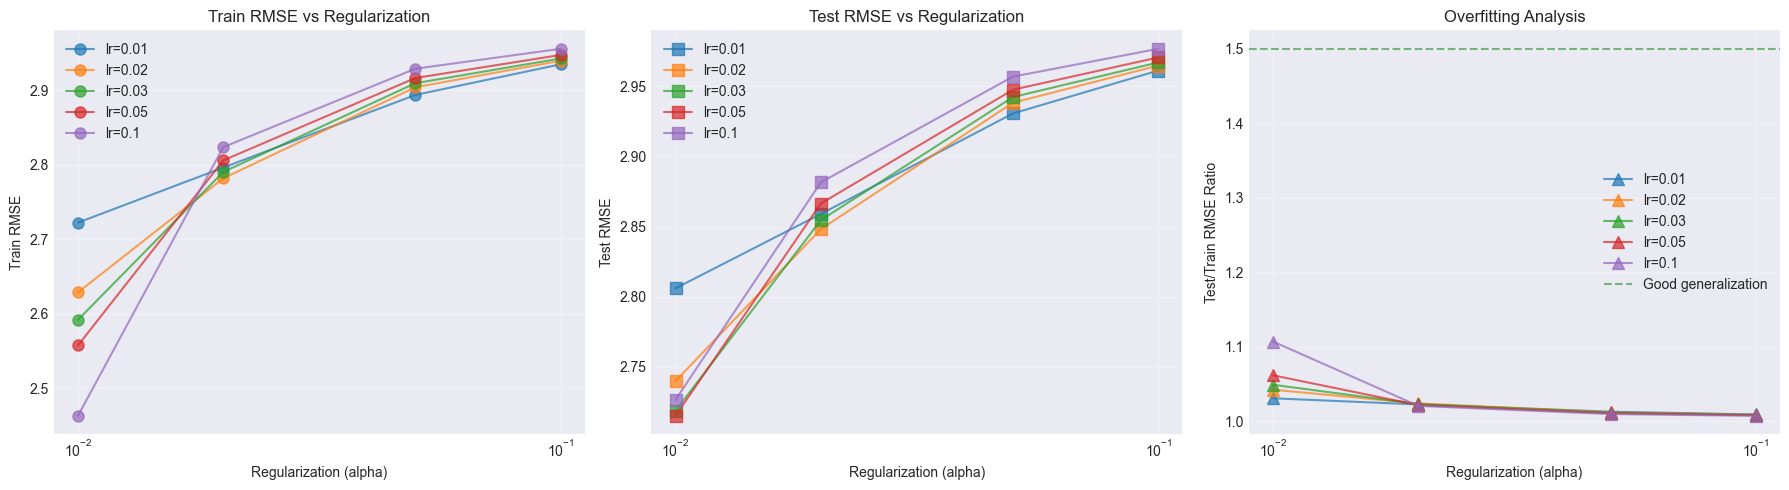

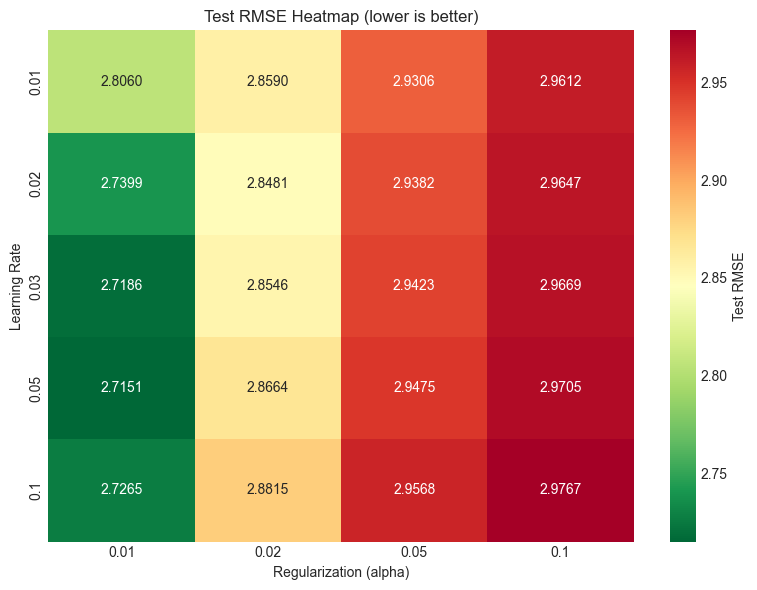

In [20]:
# Visualize hyperparameter tuning results
try:
    if len(results_df) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Group by learning rate
        for lr in sorted(results_df['learning_rate'].unique()):
            subset = results_df[results_df['learning_rate'] == lr]
            if len(subset) > 0:
                axes[0].plot(subset['alpha'], subset['train_rmse'], 'o-', 
                            label=f'lr={lr}', alpha=0.7, markersize=8)
        
        axes[0].set_xlabel('Regularization (alpha)')
        axes[0].set_ylabel('Train RMSE')
        axes[0].set_title('Train RMSE vs Regularization')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        axes[0].set_xscale('log')
        
        # Test RMSE
        for lr in sorted(results_df['learning_rate'].unique()):
            subset = results_df[results_df['learning_rate'] == lr]
            if len(subset) > 0:
                axes[1].plot(subset['alpha'], subset['test_rmse'], 's-', 
                            label=f'lr={lr}', alpha=0.7, markersize=8)
        
        axes[1].set_xlabel('Regularization (alpha)')
        axes[1].set_ylabel('Test RMSE')
        axes[1].set_title('Test RMSE vs Regularization')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        axes[1].set_xscale('log')
        
        # Overfitting
        for lr in sorted(results_df['learning_rate'].unique()):
            subset = results_df[results_df['learning_rate'] == lr]
            if len(subset) > 0:
                axes[2].plot(subset['alpha'], subset['overfitting'], '^-', 
                            label=f'lr={lr}', alpha=0.7, markersize=8)
        
        axes[2].axhline(y=1.5, color='green', linestyle='--', alpha=0.5, label='Good generalization')
        axes[2].set_xlabel('Regularization (alpha)')
        axes[2].set_ylabel('Test/Train RMSE Ratio')
        axes[2].set_title('Overfitting Analysis')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        axes[2].set_xscale('log')
        
        plt.tight_layout()
        plt.show()
        
        # Heatmap visualization with correct pivot syntax
        pivot_results = results_df.pivot(index='learning_rate', columns='alpha', values='test_rmse')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_results, annot=True, fmt='.4f', cmap='RdYlGn_r', 
                    cbar_kws={'label': 'Test RMSE'})
        plt.title('Test RMSE Heatmap (lower is better)')
        plt.xlabel('Regularization (alpha)')
        plt.ylabel('Learning Rate')
        plt.tight_layout()
        plt.show()
    else:
        print("No results to visualize. Please run the hyperparameter tuning cell first.")
except NameError:
    print("No results found. Please run the hyperparameter tuning cell first.")

## Visualize Results

## Save Hybrid Model

In [21]:
model_data = {
    'model': model,
    'user_ids': user_ids,
    'item_ids': item_ids,
    'user_to_idx': user_to_idx,
    'item_to_idx': item_to_idx,
    'user_feature_matrix': user_feature_matrix,
    'item_feature_matrix': item_feature_matrix,
    'train_data': {
        'rows': final_train_rows,
        'cols': final_train_cols,
        'ratings': final_train_ratings,
    },
    'val_data': {
        'rows': val_rows,
        'cols': val_cols,
        'ratings': val_ratings,
    },
    'test_data': {
        'rows': test_rows,
        'cols': test_cols,
        'ratings': test_ratings,
    },
    'model_params': {
        'no_components': model.no_components,
        'loss': model.loss,
        'learning_rate': model.learning_rate,
        'item_alpha': model.item_alpha,
        'user_alpha': model.user_alpha,
    },
    'feature_info': {
        'user_feature_dim': user_feature_matrix.shape[1],
        'item_feature_dim': item_feature_matrix.shape[1],
        'user_tags_count': len(all_user_tags),
        'item_tags_count': len(all_item_tags),
    },
    'performance': {
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'overfitting_ratio': test_rmse / train_rmse,
    },
}

with open('lightfm_hybrid_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Hybrid LightFM model saved to lightfm_hybrid_model.pkl")
print("\nSaved components:")
print("  - Trained model with user and item features")
print("  - User and item mappings")
print("  - Feature matrices")
print("  - Train/val/test splits")
print("  - Model parameters and performance metrics")

Hybrid LightFM model saved to lightfm_hybrid_model.pkl

Saved components:
  - Trained model with user and item features
  - User and item mappings
  - Feature matrices
  - Train/val/test splits
  - Model parameters and performance metrics
